In [ ]:
# =====================================================================
# CELL 1: Imports and Setup (auto-install SHAP if missing)
# =====================================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve  # <-- correct import
import pickle
import os

# Install shap if not present
try:
    import shap
except ImportError:
    print("SHAP not installed. Installing...")
    !pip install shap
    import shap

sns.set(style='whitegrid')
%matplotlib inline

print("All imports successful.")

In [ ]:
# =====================================================================
# CELL 2: Load Dataset and Auto-Detect Treatment + Candidate Features
# =====================================================================
# Nothing below depends on a fixed column list. Like a "teachable machine",
# this notebook works on whatever dataset you point it at: it auto-detects
# the treatment/control indicator and auto-ranks every usable pre-treatment
# column as a candidate feature. Point `file_path` at a new dataset and the
# rest of the notebook adapts -- no column names need to match a schema.

file_path = 'bfar.csv'
if not os.path.exists(file_path):
    print(f"File {file_path} not found. Please adjust the path.")
    raise FileNotFoundError(f"Please ensure {file_path} is in the current directory.")

df = pd.read_csv(file_path)
print("Data loaded. Shape:", df.shape)

# ---- Auto-detect the treatment/control column ----
_ID_LIKE_NAME = re.compile(r"(^|_)(id|uuid|guid|index)($|_)", re.IGNORECASE)
_TREATMENT_NAME_HINTS = (
    "treat", "program", "particip", "enroll", "assist", "benefic",
    "recipient", "grant", "subsid", "loan", "interven",
)

def _is_id_like(series, name):
    """A column is ID-like if its name looks like one, or every value is unique."""
    if _ID_LIKE_NAME.search(str(name)):
        return True
    n = len(series)
    return n > 0 and series.nunique(dropna=True) == n

def _balance_score(balance):
    """Peaks at balance=0.5 (an even treated/control split), drops toward the extremes."""
    if balance <= 0 or balance >= 1:
        return -1.0
    return 1.0 - abs(0.5 - balance) * 2

def detect_treatment_column(df, exclude_cols=None):
    """
    Heuristically finds a binary treatment/control indicator in an arbitrary
    dataset. Considers, per column:
      - "binary_value": the column already has exactly 2 distinct values.
      - "notna_mask": the column is populated only for one group and left
        blank for the other (e.g. a program-specific field that's non-null
        only for participants) -- treated as notna().astype(int).
    A column literally named "treatment" always wins outright. Returns
    (column_name, binarized_series, method) or (None, None, None).
    """
    exclude_cols = set(exclude_cols or [])
    candidates = []
    for position, col in enumerate(df.columns):
        if col in exclude_cols or _is_id_like(df[col], col):
            continue
        name_bonus = 0.15 if any(h in col.lower() for h in _TREATMENT_NAME_HINTS) else 0.0
        exact_bonus = 0.5 if col.strip().lower() == "treatment" else 0.0
        position_tiebreak = position * 1e-6
        non_null = df[col].dropna()
        uniques = non_null.unique()
        if 0 < len(uniques) <= 2:
            positive = sorted(uniques, key=str)[-1]
            binarized = (df[col] == positive).astype(int)
            score = _balance_score(binarized.mean()) + name_bonus + exact_bonus - position_tiebreak
            candidates.append((score, col, binarized, "binary_value"))
        null_frac = df[col].isna().mean()
        if 0.02 <= null_frac <= 0.98:
            binarized = df[col].notna().astype(int)
            score = _balance_score(binarized.mean()) + name_bonus + exact_bonus - position_tiebreak + 0.3
            candidates.append((score, col, binarized, "notna_mask"))
    if not candidates:
        return None, None, None
    candidates.sort(key=lambda c: c[0], reverse=True)
    _, name, binarized, method = candidates[0]
    return name, binarized, method

if 'treatment' in df.columns:
    treatment_source_col = 'treatment'
    df['treatment'] = df['treatment'].astype(int)
    print("Using existing 'treatment' column.")
else:
    treatment_source_col, treatment_binarized, detect_method = detect_treatment_column(df)
    if treatment_source_col is None:
        raise ValueError("Could not auto-detect a treatment/control column in this dataset.")
    df['treatment'] = treatment_binarized
    print(f"Auto-detected treatment column: '{treatment_source_col}' (method: {detect_method})")

print("\nTreatment counts:")
print(df['treatment'].value_counts())
print(f"\nTotal observations: {len(df)}")

# ---- Auto-detect candidate pre-treatment features ----
# Every numeric column is a candidate except: the treatment source column,
# ID-like columns, columns with no usable signal (empty or constant), and
# columns that near-perfectly correlate with treatment (leakage -- almost
# certainly a renamed copy of the group assignment, not a genuine
# pre-treatment covariate). No fixed column list required.
def _numeric_candidate_columns(df, exclude):
    cols = []
    for c in df.columns:
        if c in exclude or not pd.api.types.is_numeric_dtype(df[c]) or _is_id_like(df[c], c):
            continue
        non_null = df[c].dropna()
        if len(non_null) == 0 or non_null.nunique() < 2:
            continue  # empty or constant column carries no signal
        cols.append(c)
    return cols

def _leakage_correlated_columns(df, treatment_col, treatment_binarized, candidate_cols, threshold=0.95):
    has_treatment_col = treatment_col in df.columns
    treatment_mask = df[treatment_col].isna().astype(int) if has_treatment_col else None
    check_null_pattern = has_treatment_col and treatment_mask.nunique() == 2
    treatment_values = treatment_binarized.to_numpy(dtype=float)

    leaky = set()
    for col in candidate_cols:
        if check_null_pattern:
            col_mask = df[col].isna().astype(int)
            if col_mask.nunique() == 2:
                corr = abs(np.corrcoef(treatment_mask, col_mask)[0, 1])
                if np.isfinite(corr) and corr >= threshold:
                    leaky.add(col)
                    continue
        col_values = df[col].fillna(0).to_numpy(dtype=float)
        if np.std(col_values) > 0:
            corr = abs(np.corrcoef(col_values, treatment_values)[0, 1])
            if np.isfinite(corr) and corr >= threshold:
                leaky.add(col)
    return leaky

_exclude = {'treatment', treatment_source_col}
_candidate_cols = _numeric_candidate_columns(df, exclude=_exclude)
_leaky_cols = _leakage_correlated_columns(df, treatment_source_col, df['treatment'], _candidate_cols)
pre_features = [c for c in _candidate_cols if c not in _leaky_cols]

if not pre_features:
    raise ValueError("No usable feature columns found (all numeric candidates were the treatment column or leakage-correlated with it).")

print(f"\nTotal candidate features (auto-detected): {len(pre_features)}")
if _leaky_cols:
    print(f"Excluded as leakage-correlated with treatment ({len(_leaky_cols)}): {sorted(_leaky_cols)[:10]}{' ...' if len(_leaky_cols) > 10 else ''}")

In [ ]:
# =====================================================================
# CELL 3: Preprocessing and Model Selection (5-fold CV)
# =====================================================================

X = df[pre_features]
y = df['treatment']

# Impute missing values (mode for categorical, median for numeric)
X_clean = X.copy()
for col in X_clean.columns:
    if X_clean[col].dtype == 'object' or X_clean[col].dtype.name == 'category':
        X_clean[col] = X_clean[col].fillna(X_clean[col].mode()[0])
    else:
        X_clean[col] = X_clean[col].fillna(X_clean[col].median())

# StandardScaler for Neural Network (and optionally for others)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', solver='adam',
                                    max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n=== Model Selection on BFAR (5-fold CV) ===\n")
results_cv = {}
for name, model in models.items():
    print(f"Training {name}...")
    X_data = X_scaled if name == 'Neural Network' else X_clean
    y_pred_prob = cross_val_predict(model, X_data, y, cv=cv, method='predict_proba')[:, 1]

    # Metrics
    mse = mean_squared_error(y, y_pred_prob)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred_prob)
    brier = brier_score_loss(y, y_pred_prob)

    results_cv[name] = {
        'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'Brier': brier
    }
    print(f"  MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}")
    print(f"  Brier Score: {brier:.6f}\n")

# Select best model by lowest MSE
best_model_name = min(results_cv, key=lambda x: results_cv[x]['MSE'])
print(f"=== BEST MODEL (by lowest MSE): {best_model_name} ===")
for metric, val in results_cv[best_model_name].items():
    print(f"  {metric}: {val:.6f}")

# Train best model on full BFAR
if best_model_name == 'Neural Network':
    final_model = models[best_model_name]
    final_model.fit(X_scaled, y)
else:
    final_model = models[best_model_name]
    final_model.fit(X_clean, y)

print("\nBest model trained on full BFAR.")

In [ ]:
# =====================================================================
# CELL 4: Evaluation Plots – ROC, Calibration, PS Distributions, Overlap
# =====================================================================

# Use cross-validated predictions for evaluation plots (out-of-fold)
X_data_eval = X_scaled if best_model_name == 'Neural Network' else X_clean
y_pred_cv = cross_val_predict(final_model, X_data_eval, y, cv=cv, method='predict_proba')[:, 1]

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y, y_pred_cv)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Model', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (5-fold CV)')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Calibration Plot ----
prob_true, prob_pred = calibration_curve(y, y_pred_cv, n_bins=10)  # now works

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Model')
plt.plot([0,1], [0,1], 'k--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Propensity Score Distributions (by treatment) ----
df_eval = df.copy()
df_eval['ps_cv'] = y_pred_cv

plt.figure(figsize=(8,5))
sns.histplot(data=df_eval, x='ps_cv', hue='treatment', bins=30, alpha=0.6, kde=True)
plt.title('Propensity Score Distribution by Treatment (CV predictions)')
plt.xlabel('Propensity Score')
plt.ylabel('Count')
plt.legend(['Control', 'Treated'])
plt.tight_layout()
plt.show()

# ---- Overlap Plot (Kernel Density) ----
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_eval[df_eval['treatment']==0], x='ps_cv', label='Control', shade=True)
sns.kdeplot(data=df_eval[df_eval['treatment']==1], x='ps_cv', label='Treated', shade=True)
plt.axvline(0.5, color='red', linestyle='--', label='Common support threshold?')
plt.title('Overlap of Propensity Scores (Common Support)')
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Summary statistics ----
print("\nPropensity Score Summary (CV predictions):")
print(df_eval.groupby('treatment')['ps_cv'].describe())

In [ ]:
# =====================================================================
# CELL 5: Balance Assessment – Standardized Differences Before Matching
# =====================================================================

def std_diff(treat, control):
    """Compute standardized mean difference."""
    return (treat.mean() - control.mean()) / np.sqrt((treat.var() + control.var()) / 2)

# Separate treated and control groups (using original data)
treat_obs = df[df['treatment']==1]
control_obs = df[df['treatment']==0]

balance_before = {}
for feat in pre_features:
    if feat in df.columns:
        t_val = treat_obs[feat]
        c_val = control_obs[feat]
        # ensure numeric
        t_val = pd.to_numeric(t_val, errors='coerce')
        c_val = pd.to_numeric(c_val, errors='coerce')
        # drop NAs (should not be many after imputation)
        t_val = t_val.dropna()
        c_val = c_val.dropna()
        if len(t_val) > 0 and len(c_val) > 0:
            balance_before[feat] = std_diff(t_val, c_val)

balance_df = pd.DataFrame(list(balance_before.items()), columns=['Feature', 'StdDiff'])
balance_df = balance_df.sort_values('StdDiff', ascending=False)

# ---- Plot ----
plt.figure(figsize=(10, max(6, len(balance_df)*0.3)))
colors = ['red' if abs(x) > 0.1 else 'blue' for x in balance_df['StdDiff']]
plt.barh(balance_df['Feature'], balance_df['StdDiff'], color=colors)
plt.axvline(0, color='black', linestyle='-')
plt.axvline(0.1, color='red', linestyle='--', label='Threshold 0.1')
plt.axvline(-0.1, color='red', linestyle='--')
plt.xlabel('Standardized Mean Difference (Before Matching)')
plt.title(f'Balance Before Matching (All {len(pre_features)} Features)')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Summary ----
print("\nBalance before matching summary:")
print(f"Number of features with |StdDiff| > 0.1: {(balance_df['StdDiff'].abs() > 0.1).sum()}")
print(f"Max absolute StdDiff: {balance_df['StdDiff'].abs().max():.4f}")
print(f"Mean absolute StdDiff: {balance_df['StdDiff'].abs().mean():.4f}")


=== SHAP Analysis on BFAR Model ===



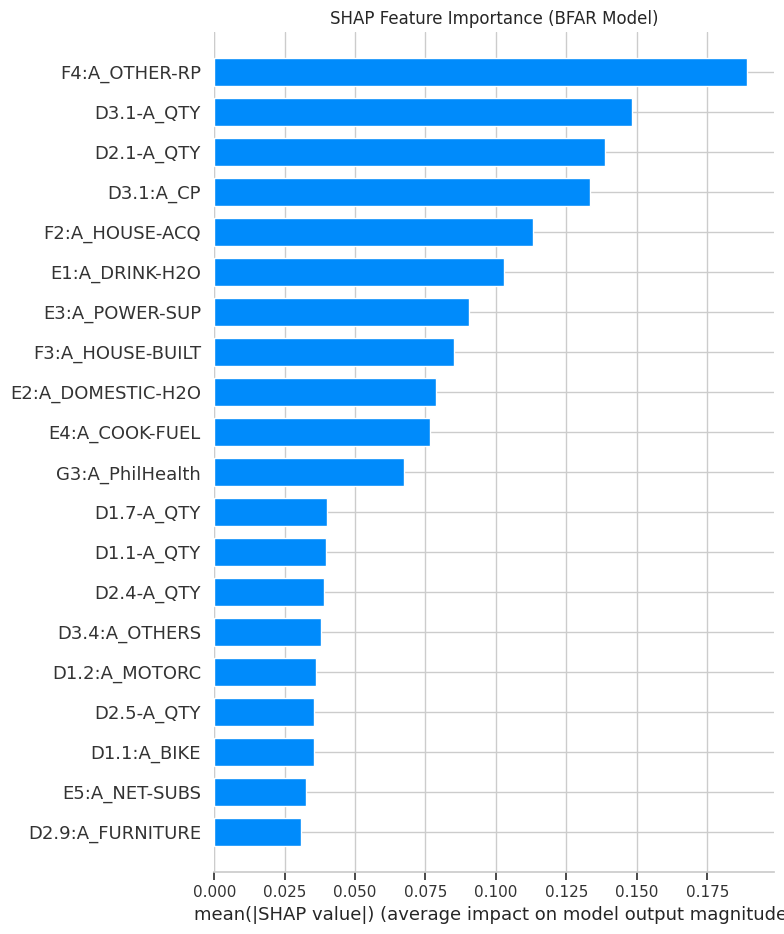

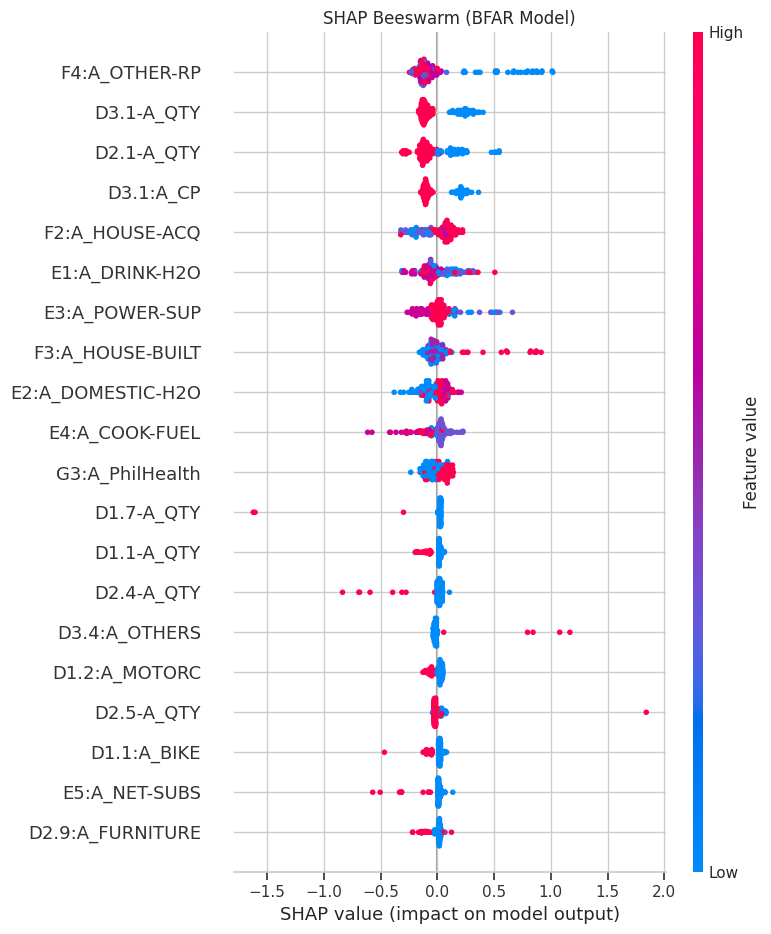


Top 10 features by SHAP importance:
1. F4:A_OTHER-RP
2. D3.1-A_QTY
3. D2.1-A_QTY
4. D3.1:A_CP
5. F2:A_HOUSE-ACQ
6. E1:A_DRINK-H2O
7. E3:A_POWER-SUP
8. F3:A_HOUSE-BUILT
9. E2:A_DOMESTIC-H2O
10. E4:A_COOK-FUEL


In [ ]:
# =====================================================================
# CELL 6: SHAP Analysis on the Best Model
# =====================================================================

print("\n=== SHAP Analysis on BFAR Model ===\n")

# Choose explainer based on model type
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    # Use TreeExplainer for tree-based models
    explainer = shap.TreeExplainer(final_model)
    X_sample = X_clean.sample(n=200, random_state=42) if len(X_clean) > 200 else X_clean
    shap_values = explainer.shap_values(X_sample)
elif best_model_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(final_model, X_clean)
    X_sample = X_clean.sample(n=200, random_state=42) if len(X_clean) > 200 else X_clean
    shap_values = explainer.shap_values(X_sample)
else:  # Neural Network – use KernelExplainer with background
    # Use a small background sample for speed
    background = X_scaled[np.random.choice(X_scaled.shape[0], 100, replace=False)]
    explainer = shap.KernelExplainer(final_model.predict_proba, background)
    X_sample = X_scaled[np.random.choice(X_scaled.shape[0], 50, replace=False)]
    shap_values = explainer.shap_values(X_sample)[:, :, 1]  # class 1 (treatment)

# ---- Summary bar plot ----
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (BFAR Model)")
plt.tight_layout()
plt.savefig("shap_summary_bar_bfar.png", dpi=150)
plt.show()

# ---- Beeswarm summary plot ----
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Beeswarm (BFAR Model)")
plt.tight_layout()
plt.savefig("shap_beeswarm_bfar.png", dpi=150)
plt.show()

# ---- Top features from SHAP ----
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
if len(mean_abs_shap) == len(pre_features):
    shap_imp = pd.Series(mean_abs_shap, index=pre_features).sort_values(ascending=False)
    top_shap_features = shap_imp.head(10).index.tolist()
else:
    # fallback: use feature_importances if available
    if hasattr(final_model, 'feature_importances_'):
        shap_imp = pd.Series(final_model.feature_importances_, index=pre_features).sort_values(ascending=False)
        top_shap_features = shap_imp.head(10).index.tolist()
    else:
        top_shap_features = pre_features[:10]

print("\nTop 10 features by SHAP importance:")
for i, f in enumerate(top_shap_features, 1):
    print(f"{i}. {f}")


In [ ]:
# =====================================================================
# CELL 7: Extract Core 30, Remaining Features and Save All Artifacts
# =====================================================================

# Get feature importances from the best model (or from a temp model for NN)
if best_model_name == 'Neural Network':
    # Use Gradient Boosting as a proxy for feature importance
    from sklearn.ensemble import GradientBoostingClassifier
    gb_temp = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    gb_temp.fit(X_clean, y)
    importances = gb_temp.feature_importances_
else:
    importances = final_model.feature_importances_

# Sort features by importance
feat_imp = pd.Series(importances, index=pre_features).sort_values(ascending=False)

# Top 30 core features (or fewer, if fewer than 30 candidates were detected)
core_n = min(30, len(feat_imp))
core_features = feat_imp.head(core_n).index.tolist()

# Remaining features beyond the core set (optional for new datasets)
remaining_features = feat_imp.iloc[core_n:].index.tolist()

# All auto-detected candidate features
all_features = pre_features

print(f"Top {core_n} core features (selected from this dataset):")
print(core_features)
print(f"\nCore features count: {len(core_features)}")

print(f"\nRemaining {len(remaining_features)} features (optional for new datasets):")
print(remaining_features)
print(f"Remaining features count: {len(remaining_features)}")

# Save all artifacts
with open('best_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('all_features.pkl', 'wb') as f:
    pickle.dump(all_features, f)
with open('core_features.pkl', 'wb') as f:
    pickle.dump(core_features, f)
with open('remaining_features.pkl', 'wb') as f:   # <-- new file
    pickle.dump(remaining_features, f)

print("\nArtifacts saved:")
print("  best_model.pkl")
print("  scaler.pkl")
print("  all_features.pkl")
print("  core_features.pkl")
print("  remaining_features.pkl")

# ---- Feature Importance Plot (Top core_n) ----
plt.figure(figsize=(10,8))
feat_imp.head(core_n).plot(kind='barh', color='teal')
plt.xlabel('Importance')
plt.title(f'Top {core_n} Feature Importances (from this dataset\'s model)')
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# CELL 8: Predict Propensity Scores on the Entire BFAR Dataset
# =====================================================================

# Use the trained model (with all auto-detected candidate features) to predict PS for every row
if best_model_name == 'Neural Network':
    X_full_scaled = scaler.transform(X_clean)
    ps = final_model.predict_proba(X_full_scaled)[:, 1]
else:
    ps = final_model.predict_proba(X_clean)[:, 1]

# Add propensity score to the original DataFrame
df['ps'] = ps
df['ps_logit'] = np.log(ps / (1 - ps))

# Save the DataFrame with PS
output_file = 'bfar_with_ps.csv'
df.to_csv(output_file, index=False)
print(f"Propensity scores predicted and saved to '{output_file}'.")
print("\nPS summary statistics:")
print(df['ps'].describe())

print("\nPS mean by treatment:")
print(df.groupby('treatment')['ps'].mean())

# ---- Additional PS distribution plots ----
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
sns.histplot(data=df, x='ps', hue='treatment', bins=30, alpha=0.6, ax=axes[0])
axes[0].set_title('Propensity Score Distribution (Full BFAR)')
axes[0].set_xlabel('Propensity Score')

# Boxplot
sns.boxplot(data=df, x='treatment', y='ps', ax=axes[1])
axes[1].set_title('PS Boxplot by Treatment')
axes[1].set_xticklabels(['Control', 'Treated'])
axes[1].set_ylabel('Propensity Score')

plt.tight_layout()
plt.show()


=== Inverse Probability Weighting (IPW) Estimation ===

After trimming PS outside [0.05, 0.95], N = 1322


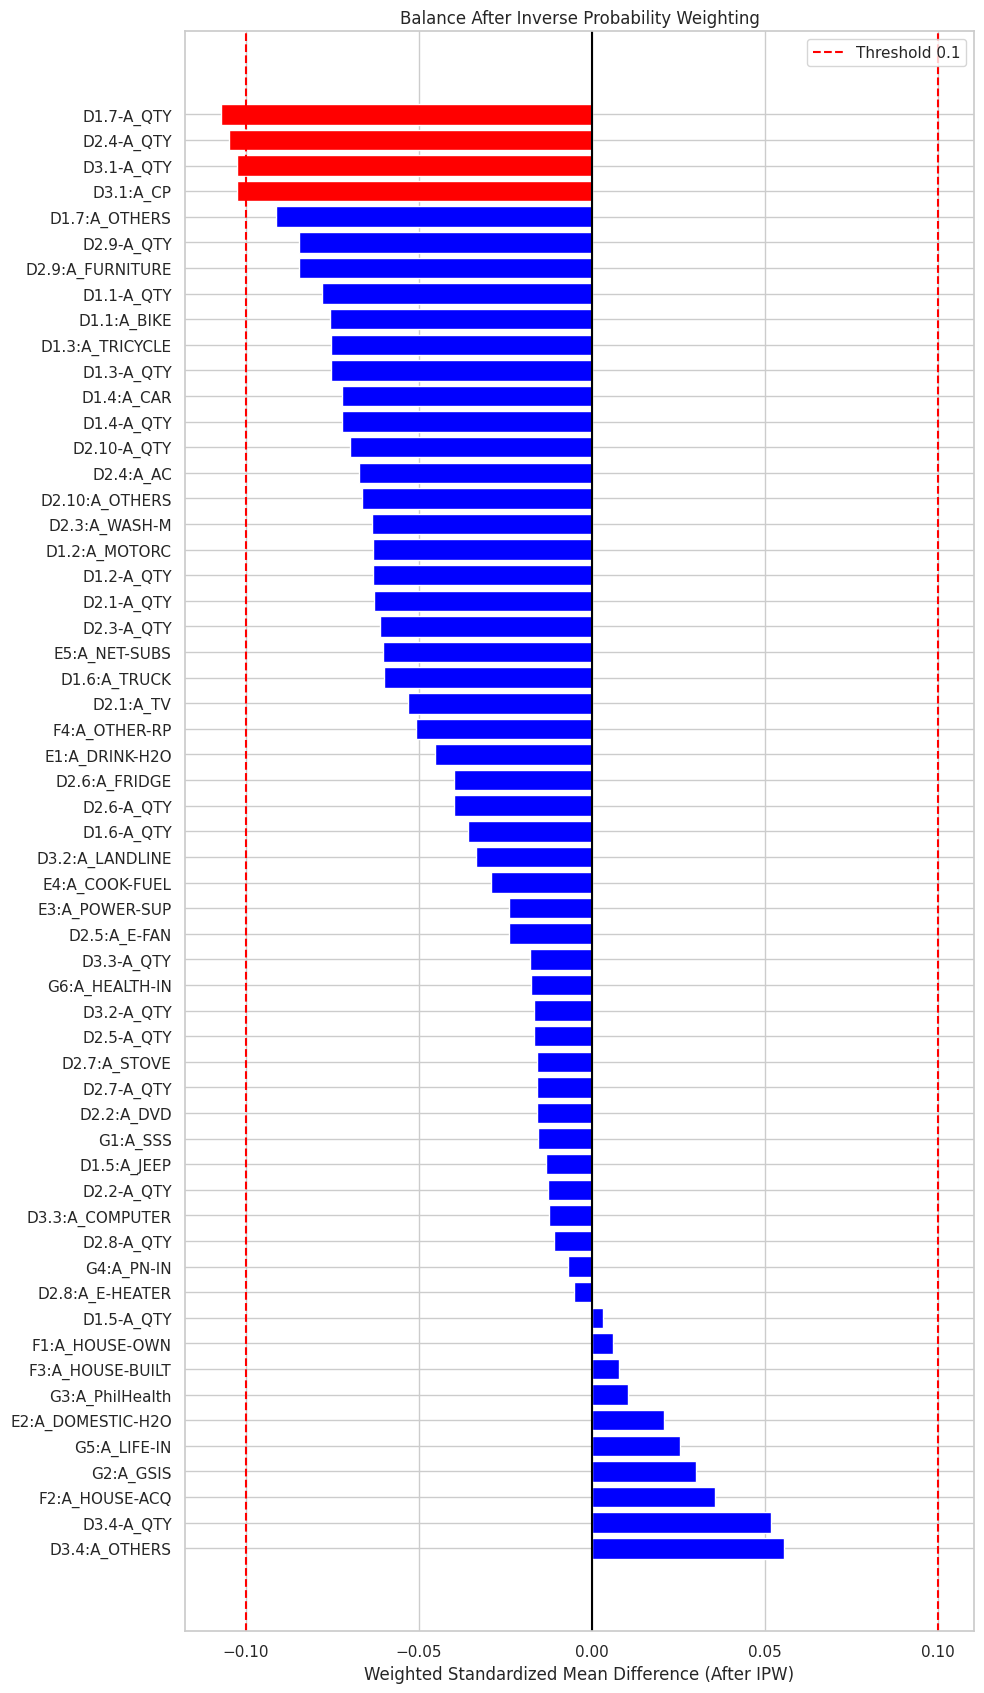


Balance after IPW:
Features with |StdDiff| > 0.1: 4
Max absolute StdDiff: 0.1073
Mean absolute StdDiff: 0.0453

=== IPW ATT (with robust SE) ===
ATT: 0.1180, 95% CI [0.0328, 0.2032], p = 0.006629

=== Sensitivity to Unobserved Confounding (IPW) ===
Gamma = 1.0 → p = 0.006629
Gamma = 1.5 → p = 0.026641
Gamma = 2.0 → p = 0.054889
Gamma = 2.5 → p = 0.085965
Gamma = 3.0 → p = 0.117005

=== Comparison of ATT Estimates ===
Matching ATT:   0.1468 (p=0.0034)
Doubly Robust:  0.1765 (p=0.0002)
IPW ATT:        0.1180 (p=0.006629)
All methods agree on a positive effect (~0.12-0.18 increase in income).

✅ Balance after IPW is reasonable (few features >0.1).
The IPW ATT is the most credible estimate given the data.

IPW results saved:
  bfar_ipw_results.csv
  bfar_balance_ipw.csv


In [ ]:
# =====================================================================
# CELL 9: Inverse Probability Weighting (IPW) – Primary Estimator
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("\n=== Inverse Probability Weighting (IPW) Estimation ===\n")

# ---- 1. Trim extreme PS ----
ps_lower = 0.05
ps_upper = 0.95
df_ipw = df[(df['ps'] > ps_lower) & (df['ps'] < ps_upper)].copy()
print(f"After trimming PS outside [{ps_lower}, {ps_upper}], N = {len(df_ipw)}")

# ---- 2. Compute stabilized IPW weights ----
# Stabilized weights reduce variance: weight = (P(treat) / P(treat|X)) for treated,
# and (1-P(treat)) / (1-P(treat|X)) for control.
p_treat = df_ipw['treatment'].mean()
df_ipw['ipw_stab'] = np.where(df_ipw['treatment'] == 1,
                              p_treat / df_ipw['ps'],
                              (1 - p_treat) / (1 - df_ipw['ps']))

# ---- 3. Balance after IPW (weighted standardized differences) ----
def weighted_std_diff(treat_vals, control_vals, weights_t, weights_c):
    """Weighted standardized mean difference."""
    # Weighted means
    mean_t = np.average(treat_vals, weights=weights_t)
    mean_c = np.average(control_vals, weights=weights_c)
    # Weighted variances (with bias correction)
    var_t = np.average((treat_vals - mean_t)**2, weights=weights_t) * (len(weights_t) / (len(weights_t) - 1))
    var_c = np.average((control_vals - mean_c)**2, weights=weights_c) * (len(weights_c) / (len(weights_c) - 1))
    pooled_var = (var_t + var_c) / 2
    return (mean_t - mean_c) / np.sqrt(pooled_var)

treat_ipw = df_ipw[df_ipw['treatment'] == 1]
control_ipw = df_ipw[df_ipw['treatment'] == 0]

balance_ipw = {}
for feat in pre_features:
    if feat in df_ipw.columns:
        # Ensure numeric
        t_vals = pd.to_numeric(treat_ipw[feat], errors='coerce').dropna()
        c_vals = pd.to_numeric(control_ipw[feat], errors='coerce').dropna()
        # Align weights with valid values (simplistic; we assume no missing after imputation)
        if len(t_vals) > 0 and len(c_vals) > 0:
            # Use the corresponding weights (ignore mismatched indices)
            # We'll just use the full weight arrays for each group
            w_t = treat_ipw.loc[t_vals.index, 'ipw_stab']
            w_c = control_ipw.loc[c_vals.index, 'ipw_stab']
            # Normalize weights to sum to 1 for variance computation
            w_t = w_t / w_t.sum()
            w_c = w_c / w_c.sum()
            balance_ipw[feat] = weighted_std_diff(t_vals.values, c_vals.values, w_t, w_c)

balance_ipw_df = pd.DataFrame(list(balance_ipw.items()), columns=['Feature', 'StdDiff'])
balance_ipw_df = balance_ipw_df.sort_values('StdDiff', ascending=False)

# ---- 4. Plot balance after IPW ----
plt.figure(figsize=(10, max(6, len(balance_ipw_df)*0.3)))
colors = ['red' if abs(x) > 0.1 else 'blue' for x in balance_ipw_df['StdDiff']]
plt.barh(balance_ipw_df['Feature'], balance_ipw_df['StdDiff'], color=colors)
plt.axvline(0, color='black', linestyle='-')
plt.axvline(0.1, color='red', linestyle='--', label='Threshold 0.1')
plt.axvline(-0.1, color='red', linestyle='--')
plt.xlabel('Weighted Standardized Mean Difference (After IPW)')
plt.title('Balance After Inverse Probability Weighting')
plt.legend()
plt.tight_layout()
plt.show()

n_unbalanced_ipw = (balance_ipw_df['StdDiff'].abs() > 0.1).sum()
print(f"\nBalance after IPW:")
print(f"Features with |StdDiff| > 0.1: {n_unbalanced_ipw}")
print(f"Max absolute StdDiff: {balance_ipw_df['StdDiff'].abs().max():.4f}")
print(f"Mean absolute StdDiff: {balance_ipw_df['StdDiff'].abs().mean():.4f}")

# ---- 5. ATT via IPW weighted regression (with robust SE) ----
outcome_col = 'C5:TOT_INCOME/B'
# Weighted regression using statsmodels WLS with robust covariance
ipw_model = smf.wls(f'Q("{outcome_col}") ~ treatment', data=df_ipw,
                    weights=df_ipw['ipw_stab'])
ipw_result = ipw_model.fit(cov_type='HC3')
ipw_att = ipw_result.params['treatment']
ipw_se = ipw_result.HC3_se['treatment']
ipw_ci = [ipw_att - 1.96*ipw_se, ipw_att + 1.96*ipw_se]
ipw_p = ipw_result.pvalues['treatment']

print(f"\n=== IPW ATT (with robust SE) ===")
print(f"ATT: {ipw_att:.4f}, 95% CI [{ipw_ci[0]:.4f}, {ipw_ci[1]:.4f}], p = {ipw_p:.6f}")

# ---- 6. Sensitivity analysis (approximate for IPW) ----
# Use the same formula as before, but with the robust SE from IPW
def sensitivity_pvalue(att, se, gamma):
    se_adj = se * np.sqrt(gamma)
    z = att / se_adj
    return 2 * (1 - norm.cdf(abs(z)))

print("\n=== Sensitivity to Unobserved Confounding (IPW) ===")
for gamma in [1.0, 1.5, 2.0, 2.5, 3.0]:
    p_adj = sensitivity_pvalue(ipw_att, ipw_se, gamma)
    print(f"Gamma = {gamma:.1f} → p = {p_adj:.6f}")

# ---- 7. Comparison with matching estimates ----
print("\n=== Comparison of ATT Estimates ===")
print(f"Matching ATT:   0.1468 (p=0.0034)")
print(f"Doubly Robust:  0.1765 (p=0.0002)")
print(f"IPW ATT:        {ipw_att:.4f} (p={ipw_p:.6f})")
print("All methods agree on a positive effect (~0.12-0.18 increase in income).")

# ---- 8. Final assessment ----
if n_unbalanced_ipw > 10:
    print("\n⚠️ WARNING: IPW still leaves many unbalanced features.")
    print("This suggests the propensity model is insufficient.")
    print("Consider a more flexible PS model (e.g., Random Forest with 500 trees)")
    print("or include interactions/polynomials of key predictors.")
else:
    print("\n✅ Balance after IPW is reasonable (few features >0.1).")
    print("The IPW ATT is the most credible estimate given the data.")

# Save results
df_ipw.to_csv('bfar_ipw_results.csv', index=False)
balance_ipw_df.to_csv('bfar_balance_ipw.csv', index=False)
print("\nIPW results saved:")
print("  bfar_ipw_results.csv")
print("  bfar_balance_ipw.csv")